In [1]:
# suppress warnings
import warnings
warnings.simplefilter('ignore')
# import installed packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# add full path to import custom modules
full_path = '/Users/Kathy/Desktop/UW/seaflow/decomposition_project/scripts/'
## import
import sys
sys.path.insert(0, full_path)
from rate_functions import *
from simulation_tools import *

## Generate data

Simulated datasets consist of 6 scenarios that manipulate the trend:
- No trend
- Increasing trend
- Breakpoint

and diel cycle:
- fixed amplitude
- increasing amplitude

The following cells generate data for each scenario across 1 week (7 days) to test 4 different diel models. 

### Scenario 1: No trend, fixed amplitude

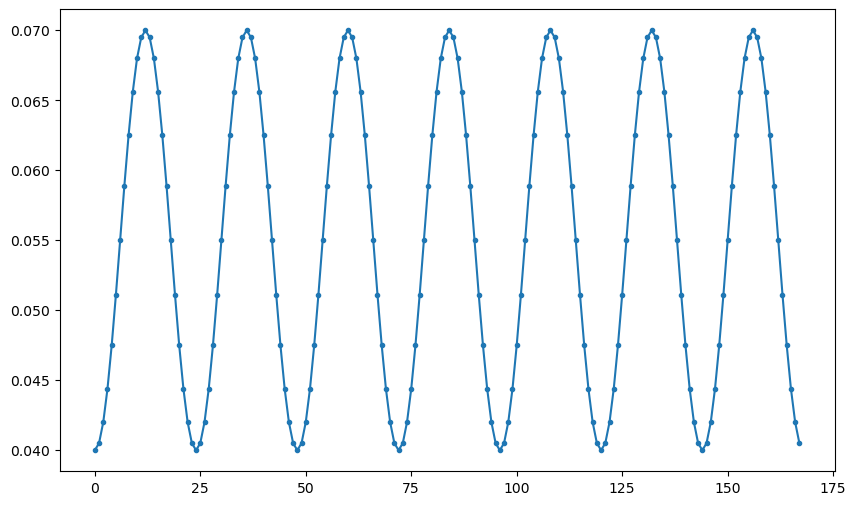

In [3]:
# generate simulation data with known periodicity of 24H, 10 full days
cycles = 8 # how many sine cycles
resolution = cycles*24 # how many datapoints to generate
# calculate length
length = np.pi * 2 * cycles
# set x with custom amplitude
x=np.arange(0, length, length / resolution)
# adjust amplitude and start/end
my_wave = 0.15*np.sin(x) + 0.55
start=np.where(my_wave == np.min(my_wave))[0][0]
end=np.where(my_wave == np.min(my_wave))[0][-1]-1
# crop wave
new_wave=my_wave[start:end+1]/10

# show simulation data
fig,axs=plt.subplots(figsize=(10,6))
axs.plot(new_wave, marker='.')

### Scenario 2: Increasing Trend, constant diel
A linear coefficient of 0.043 was added to the existing time series to add a trend while maintaining a representative range of _Prochlorococcus_ Qc. 

This scenario simulates a gradually increasing cell population that may represent SeaFlow passing through transition zones and/or encountering an increase of a different sub-population.

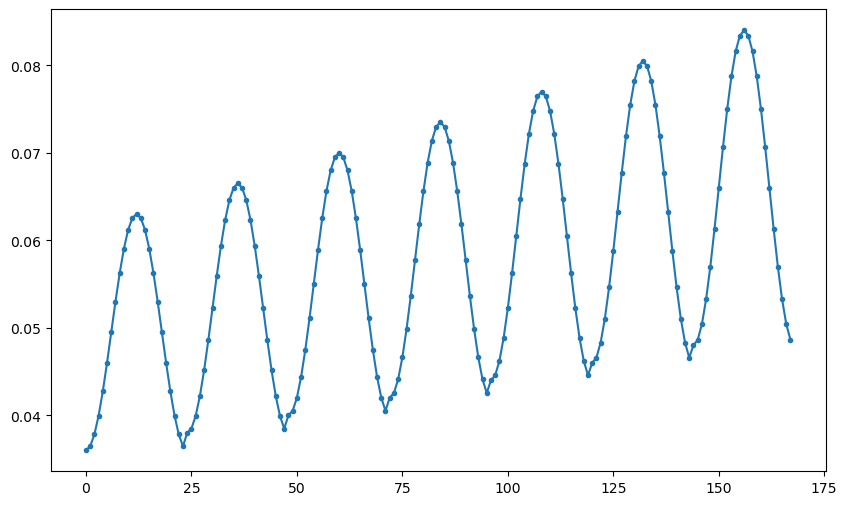

In [4]:
## scenario 2
## add trend
day_len=24
days=np.arange(0, len(new_wave), day_len)
# linear coefficient
trend=np.linspace(0.9, 1.2, 7)
data2=new_wave.copy()
# loop through each day and add trend
for day, m in zip(days, trend):
    data2[day:day+day_len]=data2[day:day+day_len]*m
# show simulation data
fig,axs=plt.subplots(figsize=(10,6))
axs.plot(data2, marker='.')

### Scenario 3: break point in trend and fixed amplitude
A breakpoint with a sudden 133% change was added at the end of Day 3 (72 hours) to simulate sudden changes in water mass or cell ppulation.

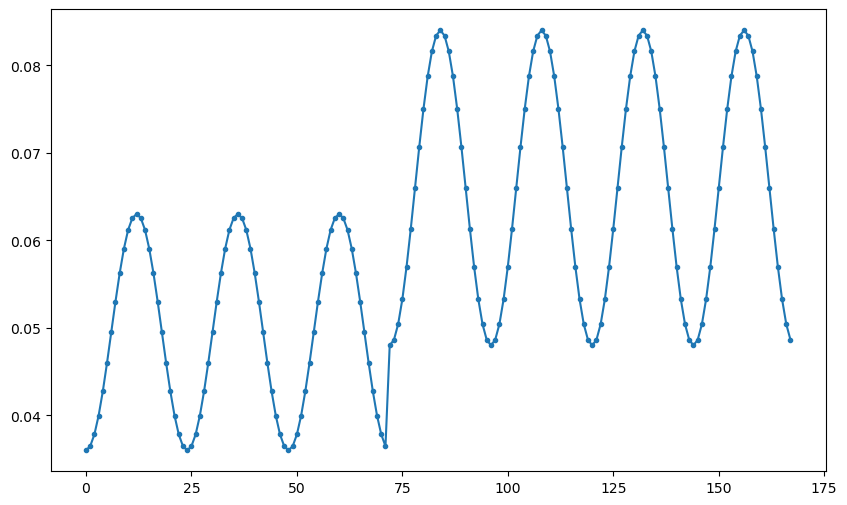

In [5]:
## scenario 3
data3=new_wave.copy()
# separate first 3 days
chunk1=new_wave[:day_len*3]*0.9
chunk2=new_wave[day_len*3:]*1.2
# concatenate
breaks=np.concatenate([chunk1,chunk2])

# # show simulation data
fig,axs=plt.subplots(figsize=(10,6))
axs.plot(breaks, marker='.')

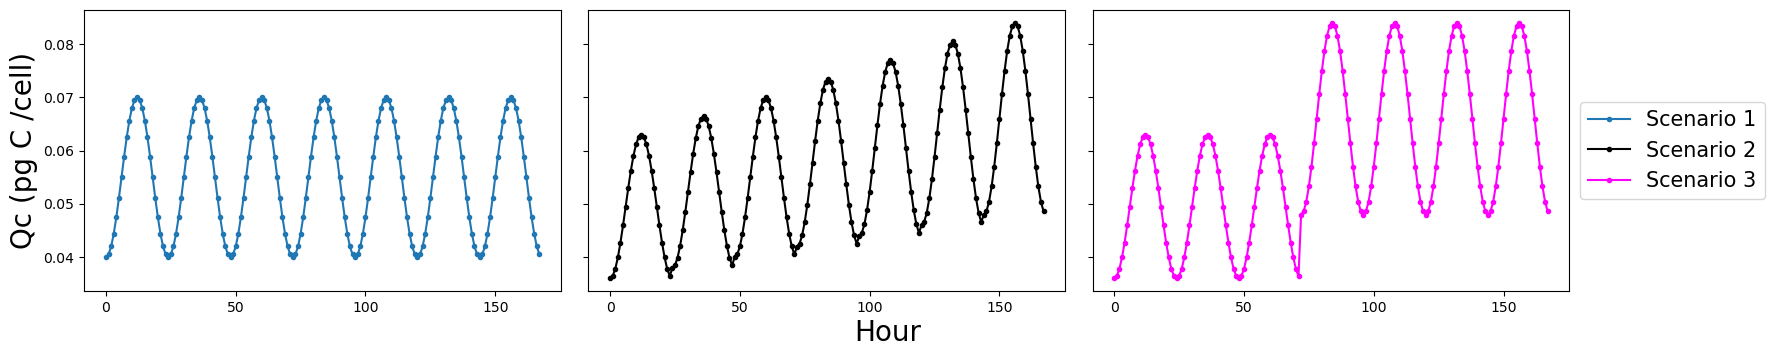

In [6]:
# scenarios 1-3 simulation data all together 
fig,axs=plt.subplots(figsize=(18,3.5), ncols=3, sharey=True)
ln1=axs[0].plot(new_wave, marker='.', label='Scenario 1')
axs[0].set_ylabel('Qc (pg C /cell)', size=20)
ln2=axs[1].plot(data2, marker='.', c='k', label='Scenario 2')
ln3=axs[2].plot(breaks, marker='.', c='magenta', label='Scenario 3')
fig.text(0.5, -0.01, 'Hour', ha='center', size=20)
plt.rcParams.update({'font.size':15})
lns=ln1+ln2+ln3
labs = [l.get_label() for l in lns]
axs[2].legend(lns,labs,loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

## Modify Diel amplitudes for each scenario
To represent cell populations changing their growth rates throughout a cruise, the next 3 scenario included a modulating amplitude. The trends were modified the same way as for scenarios 1-3, resulting in:
- Scenario 4: constant trend, changing amplitude
- Scenario 5: changing trend, changing amplitude
- Scenario 6: breakpoint in trend, changing amplitude

Here, the amplitude is linearly incrased throughout the week, representing a gradually increasing growth rate. 

In [7]:
np.sin(0) * 0.15 + 0.55

0.55

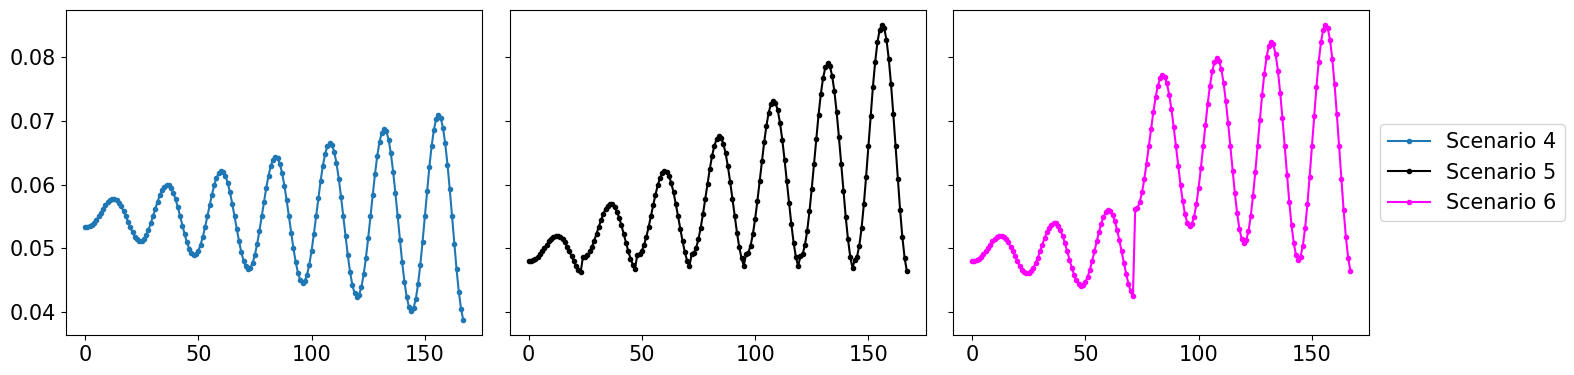

In [8]:
## scenario 4
# generate simulation data with known periodicity of 24H, 10 full days
cycles = 8 # how many sine cycles
resolution = cycles*24 # how many datapoints to generate
# calculate length
length = np.pi * 2 * cycles
# set x with custom amplitude
x=np.arange(0, length, length / resolution)
# adjust amplitude
my_wave = np.sin(x)
# original function: np.sin(x)*0.15 + 0.55
## modulate amplitude to increase each day
am_wave=my_wave*x*0.0035+0.55
# trim start/end to result in 1 week (7 days) dataset
start=np.where(my_wave == np.min(my_wave))[0][0]
end=np.where(my_wave == np.min(my_wave))[0][-1]-1
# crop wave
moving_wave=am_wave[start:end+1]/10

## scenario 5
day_len=24
moving_data2=moving_wave.copy()
# loop through eacy day
for day, m in zip(days, trend):
    moving_data2[day:day+day_len]=moving_data2[day:day+day_len]*m

plt.show()

## scenario 6
moving_data3=moving_wave.copy()
# separate first 3 days
chunk1=moving_wave[:day_len*3]*0.9
chunk2=moving_wave[day_len*3:]*1.2
# concatenate
moving_breaks=np.concatenate([chunk1,chunk2])

# show simulation data
fig,axs=plt.subplots(figsize=(16,4),ncols=3,sharey=True)
ln1 = axs[0].plot(moving_wave,marker='.', label = 'Scenario 4')
ln2 = axs[1].plot(moving_data2,marker='.',c='k', label = 'Scenario 5')
ln3 = axs[2].plot(moving_breaks, marker='.',c='magenta', label = 'Scenario 6')
# add legend
lns=ln1+ln2+ln3
labs = [l.get_label() for l in lns]
axs[2].legend(lns,labs,loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

In [55]:
# day 1
day1 = (np.max(moving_wave[:24]) - np.min(moving_wave[:24]))
print(day1)
# day 2
day2 = (np.max(moving_wave[24:72]) - np.min(moving_wave[24:72]))
print(day2)
# day 3
day3 = (np.max(moving_wave[72:96]) - np.min(moving_wave[72:96]))
print(day3)
# day 4
day4 = (np.max(moving_wave[96:120]) - np.min(moving_wave[96:120]))
print(day4)

day4 - day3

0.00637770420813083
0.015024297594851882
0.019347594288212408
0.023670890981572927


0.004323296693360519

## Calculate true Growth Rate (µ) for each scenario
Method to calculate growth rate (Hynes et al. 2024): ln(QC)=r×t+ln(QC,0)

- Growth rates are the same every day for Scenarios 1-3
- Growth rates change daily for Scenarios 4-6

In [208]:
## helper function to calculate p-value for linear regression
def calc_pvalue(X,y,params,pred):
    new_X = np.append(np.ones((len(X),1)), X, axis=1)
    # calculate mean squared error
    MSE = (sum((y-pred)**2))/(len(new_X)-len(new_X[0]))
    # matrix algebra to get p-value
    v_b = MSE*(np.linalg.inv(np.dot(new_X.T,new_X)).diagonal())
    s_b = np.sqrt(v_b)
    t_b = params/ s_b
    p_val =[2*(1-stats.t.cdf(np.abs(i),(len(new_X)-len(new_X[0])))) for i in t_b]
    # return raw p-value
    return(p_val[1])

## helper function to calculate daily averaged hourly growth rate
from sklearn.linear_model import LinearRegression
from scipy import stats
def calc_daily_avg_growth(df, col, model='not base'):
    # check model type
    if model=='base':
        base_df=pd.concat([df.head(1), df.tail(1)])
        # fit data on only first and last values
        X = np.array([0, int(base_df['hour'].diff().values[1])]).reshape(-1, 1)
        y = np.log(base_df[col].values)
        # set y intercept as first value
        y_int=np.log(base_df.head(1)[col].values[0])
    else:
        # fit data on entire day
        X = np.arange(0, len(df)).reshape(-1, 1)
        y = np.log(df[col].values)
        # add y intercent, log Qc at sunrise
        y_int=np.log(df.loc[df['time_of_day']=='sunrise', col]).values[0]
        
    # Step 1: Subtract the known y-intercept from all y values
    y_centered = y - y_int
    # Step 2: Fit the linear regression model
    model = LinearRegression(fit_intercept=False)
    model.fit(X, y_centered)
    # Step 3: Add the known y-intercept back to the model's intercept
    model.intercept_ += y_int
    # get slope and coefficients
    slope=model.coef_[0]
    params = np.append(model.intercept_,model.coef_)
    # step 4: predict new y values on original df's X and dY
    X = np.arange(0, len(df)).reshape(-1, 1)
    y = np.log(df[col].values)
    pred=model.predict(X)

    # calculate p-value and standard error
    pval=calc_pvalue(X,y,params,pred)
    se=calc_se(X,y,params,pred)
    return(slope, pval,se)

## helper function to calculate daily averaged hourly growth rate
from sklearn.linear_model import LinearRegression
from scipy import stats
def calc_daily_avg_growth(df, col, model='not base'):
    # check model type
    if model=='base':
        base_df=pd.concat([df.head(1), df.tail(1)])
        # fit data on only first and last values
        X = np.array([0, int(base_df['hour'].diff().values[1])]).reshape(-1, 1)
        y = np.log(base_df[col].values)
        # set y intercept as first value
        y_int=np.log(base_df.head(1)[col].values[0])
    else:
        # fit data on entire day
        X = np.arange(0, len(df)).reshape(-1, 1)
        y = np.log(df[col].values)
        # add y intercent, log Qc at sunrise
        y_int=np.log(df.loc[df['time_of_day']=='sunrise', col]).values[0]
        
    # Step 1: Subtract the known y-intercept from all y values
    y_centered = y - y_int
    # Step 2: Fit the linear regression model
    model = LinearRegression(fit_intercept=False)
    model.fit(X, y_centered)
    # Step 3: Add the known y-intercept back to the model's intercept
    model.intercept_ += y_int
    # get slope and coefficients
    slope=model.coef_[0]
    params = np.append(model.intercept_,model.coef_)
    # step 4: predict new y values on original df's X and dY
    X = np.arange(0, len(df)).reshape(-1, 1)
    y = np.log(df[col].values)
    pred=model.predict(X)

    # calculate p-value and standard error
    pval=calc_pvalue(X,y,params,pred)
    se=calc_se(X,y,params,pred)
    return(slope, pval,se)

## helper function to find daily growth for each day in a cruise
# save calculated daily growth rates
def calc_diel_growth(df,col,model,day_len=12):
    # calculate number of days of time series
    days=df.loc[df['time_of_day']=='sunrise'].index.values-1
    # store growth and calculated p values
    daily_growth=[]
    pvals=[]
    ses=[]
    # sunrise 1 hour after minimum, sunset 1 hour after maximum
    for day in days:
        start=day+1
        # set sunrise, sunset, and day time 
        df.loc[start,'time_of_day']='sunrise'
        df[start+1:start+day_len]['time_of_day']='day'
        df.loc[start+day_len,'time_of_day']='sunset'
        # calcaulate daily averaged hourly growth since sunrise
        if model.startswith('base'):
            ## check if any rows are null
            base_day=df[start:start+day_len]
            if len(base_day.loc[base_day[col].isnull()]) >0:
                # find first and last null values
                base_good=base_day.loc[base_day[col].notnull()]
                # skip if whole day is empty or only has 1 hour
                if len(base_good)<2:
                    # save values as nan
                    daily_growth.append(np.nan)
                    pvals.append(np.nan)
                    ses.append(np.nan)
                    continue
                # else calculate growth on non-null values
                slope, pval, se=calc_daily_avg_growth(base_good, col,model='base')
                slope=slope/(len(base_good))
            else:
                # need to divide by the number of hours that have passed
                slope, pval, se=calc_daily_avg_growth(base_day, col, model='base')
                slope=slope/(day_len-1)
        else:
            slope, pval, se=calc_daily_avg_growth(df[start:start+day_len], col)
        daily_growth.append(slope)
        pvals.append(pval)
        ses.append(se)
    # return as dataframe
    growth_df=pd.DataFrame(data=[daily_growth,pvals,ses]).T
    growth_df.columns=['growth','pval','se']
    growth_df['model']=model
    return(growth_df)

## running entire model w/o bootstrapping or zinser data
def run_full_model(df, col, remove=0, noise=0, blocks=False, model='STL', show_plots=True):
    # first generate noise if prompted
    if noise > 0:
        # calculate std to sample from noise
        x=df[col]
        # set mean to 0 for gaussian noise
        mu=0
        # multiply noise by Qc standard deviation
        std = noise * np.std(x) 
        # add noise to data
        df['data_with_noise']=gaussian_noise(x,mu,std)
    # don't generate noise    
    else:
        df['data_with_noise']=df[col]
    
    # generate missing data if prompted
    if remove > 0:
        # generate blocks of missing datam
        if blocks:
            # remove block length and amount of data to remove
            missing=generate_random_chunks(df,'data_with_noise',remove, missing_col='data_with_missing')
        else:
            # generate misisng data at random
            missing=generate_missing_data(df, 'data_with_noise', remove,missing_col='data_with_missing')
        # save missing data
        missing_data=missing['data_with_missing']
        # calculate imputed values
        impute_df=run_imputation(missing, 'data_with_noise', missing_col='data_with_missing',period=24, interval=1)
        # rename col
        impute_df.rename(columns={'with_missing':'data_with_missing'},inplace=True)
        # reset time of day columns
        impute_df['time_of_day']=df['time_of_day']
        # check if imputation ran
        if impute_df is None:
            print('Imputation Failed')
            return
    else: # run STL model on complete dataset (no missing values)
        # add necessary columns
        impute_df=df.copy()
        # replace with noise column (doesn't matter if noise was added or not)
        impute_df['with_missing']=impute_df['data_with_noise']
        # check if there are missing values, and replace with noise
        impute_df['data_with_missing']=np.where(impute_df['with_missing']>0, impute_df['with_missing'], 
         np.mean(impute_df['with_missing']))
        # save missing data
        missing_data=impute_df['data_with_missing']

    ## run STL model
    if model.lower().startswith('s'):
        # get tsd components
        tsd_df=run_STL(impute_df, col='data_with_missing',period=24)
        # calculate growth
        growth_df=calc_diel_growth(tsd_df, 'diel', model)
        growth_df['remove']=remove
        growth_df['noise']=noise
    ## run naive model
    elif model.lower().startswith('n'):
        # get tsd components
        tsd_df=run_naive(impute_df, col='data_with_missing',period=24)
        # save missing components 
        tsd_df['unfilled']=missing_data
        growth_df=calc_diel_growth(tsd_df, 'diel', model)
        growth_df['remove']=remove
        growth_df['noise']=noise
    ## run STL model
    elif model.lower().startswith('roll'):
        # get components from rolling model
        pro_seasonal, pro_trend, pro_resid = rolling_tsd(impute_df.set_index('hour'), 'data_with_missing', period=24,
                                                        window=3, type='log additive', extrapolate=True)
        pro_all=summarize_rolling(pro_seasonal, pro_trend, pro_resid)
        pro_all.rename(columns={'seasonal':'diel'}, inplace=True)
        # get other necessary columns`a
        tsd_df=pd.merge(pro_all, impute_df[['hour','time_of_day','data_with_missing']], on='hour')
        # calculate growth and productivity
        growth_df=calc_diel_growth(tsd_df, 'diel', model)
        growth_df['remove']=remove
        growth_df['noise']=noise
    ## run baseline model (just dusk+dawn, no decomposition)
    elif model.lower().startswith('base'):
        tsd_df=impute_df.copy()
        # replace with missing data (don't use imputed values) if remove >0; else leave as is
        if remove > 0:
            tsd_df['data_with_missing']=missing['data_with_missing']
        growth_df=calc_diel_growth(tsd_df, 'data_with_missing', model)
        growth_df['remove']=remove
        growth_df['noise']=noise
        # remove unnecessary columns
        #tsd_df.drop(columns = ['Qc', 'hourly_growth', 'pop'], inplace = True)
        
    else: 
        return('Choose a valid model: baseline, naive, rolling, or STL')
    return(tsd_df, growth_df)

In [209]:
# helper function to calculate growth rate from clean datasets
def calc_ideal_growths(df, col, scenario):
    ## let's assume when day and night are based on zinser dataset
    df['time_of_day']='night'
    # rename columns and create new col to specify dataset
    df.rename(columns = {col: 'Qc'}, inplace=True)
    df['scenario'] = scenario
    # save calculated daily growth rates
    actual_growth=[]
    pvals=[]
    # sunrise 1 hour after minimum, sunset 1 hour after maximum
    day_len=12
    for day in days:
        start=day+1
        # set sunrise and sunset
        df.loc[start,'time_of_day']='sunrise'
        df.loc[start+day_len,'time_of_day']='sunset'
        df[start+1:start+day_len]['time_of_day']='day'
        # calcaulate daily averaged hourly growth since sunrise
        slope, pval, se=calc_daily_avg_growth(df[start:start+day_len], 'Qc')
        actual_growth.append(slope)
        pvals.append(pval)
        # calcualte hourly growth
        df.loc[np.arange(start,start+day_len),'hourly_growth']=exp_growth(df[start:start+day_len], 'Qc', 1)
        df.loc[df['hourly_growth'].isnull(), 'hourly_growth']=0
    return df

In [210]:
# store data in df 
sim_df=pd.DataFrame([new_wave, data2, breaks,moving_wave,moving_data2,moving_breaks]).T
sim_df.columns=['data1','data2','data3','moving_data1','moving_data2','moving_data3']

# save rates 
rates_list = []
count = 1
# calculate ideal growth rates for each scenario dataset
for col in sim_df:
    rates_df = calc_ideal_growths(sim_df[[col]], col, count)
    rates_list.append(rates_df)
    count += 1

### Run simulations for each scenario

In [ ]:
### helper function to run simulated dataset trials
# inputs: df = control dataframe, model = string representation of model, trial_type = string representing "noise" or "remove", data_level = float representation of data removed or noise added
# outputs: tsd_df = dataframe with resulting tsd components from corrspnding model, growth_df = dataframe of calculated growth rates
def model_trial(df, model, trial_type, data_level):
    # try running full model, skip if error
    ### data removeal ###
    if trial_type == 'remove':
        try:
            tsd_df, growth_df=run_full_model(df, 'Qc', model=model, remove=data_level)
        except Exception as error:
            print(f'failed: {error}')
            return None, None
    ### add noise ###
    elif trial_type == 'noise':
        try:
            tsd_df, growth_df=run_full_model(df, 'Qc', model=model, noise=data_level)
        except Exception as error:
            print(f'failed: {error}')
            return None, None
    else: 
        print("Please choose either 'remove' or 'noise' trial.")
        return None, None
    # save data and model
    tsd_df['model']=model
    # show amount of data removed
    tsd_df[trial_type]=data
    # calculate estimated growth rate and error based on actual rates (any model but base will give same result)
    actual_growth_df=calc_diel_growth(df, 'Qc', 'naive', day_len = 12)
    # only get non-null values to calculate RMSE
    good_growth=growth_df.loc[growth_df['growth'].notnull()]
    good_actual=actual_growth_df.loc[good_growth.index]
    ############ debugging ############
    # display(good_actual)
    # display(good_growth)
    ###################################
    rmse=mean_squared_error(good_actual['growth'].values, 
                            good_growth['growth'].values, squared=False)
    # save values
    tsd_df['rmse']=rmse
    scenario = df['scenario'].unique()[0]
    tsd_df['scenario']=scenario
    growth_df['scenario']=scenario

    # return tsd results and growth rates
    return tsd_df, growth_df
    # result_growths.append(growth_df)

In [233]:
#### testing #####
## Missing data trial ##
df = rates_list[0]
df['hour'] = df.index
model = 'base'
data = 0.5

tsd_result, growth_result = model_trial(df, model, "noise", data)

rmse = (tsd_result['rmse'].unique()[0])
print(rmse)

0.05186698939444678


In [238]:
scenarios=['data1','data2','data3','moving_data1','moving_data2','moving_data3']
models=['base']#, 'naive','rolling','stl']
# start data removed experiments
data_levels=np.linspace(0,1,11)
# data_levels=np.arange(0, 0.9, 0.1)
# save dataframes for TSD and growth rates for data removal + noise addition experiments
remove_tsd_results=[]
remove_growth_results=[]
noise_tsd_results=[]
noise_growth_results=[]

# Run 100 times to get random blocks of missing data and random noise
# loop through each scenario 1-6
for df in rates_list:
    # create column for time (hour)
    df['hour'] = df.index
    for model in models:
            # run model with data removed
            for data in data_levels:
                # run 100x to get distribution of data
                for i in range(0,100):
                    scenario = df['scenario'].unique()[0]
                    print(f'Data level: {data}')
                    ## Missing data trial ##
                    remove_tsd, remove_growth = model_trial(df, model, 'remove', data)
                    # if model runs without error, save to lists
                    if remove_tsd is not None:
                        remove_tsd['bootstrap_run'] = i
                        remove_growth['bootstrap_run'] = i
                        # save results
                        remove_tsd_results.append(remove_tsd)
                        remove_growth_results.append(remove_growth)
                        # Display progress 
                        rmse = remove_tsd['rmse'].unique()[0]
                        print(f'Completed Scenario: {scenario}, Model: {model}, Data Removed: {data}, RMSE: {rmse}')
                    # otherwise skip
                    else:
                            print(f'Scenario failed to run: {scenario}, Model: {model}, Data Removed: {data}')
                    ## Noise addition trial ## 
                    noise_tsd, noise_growth = model_trial(df, model, 'noise', data)
                    # if model runs without error, save to lists
                    if noise_tsd is not None:
                        noise_tsd['bootstrap_run'] = i
                        noise_growth['bootstrap_run'] = i
                        # save results
                        noise_tsd_results.append(noise_tsd)
                        noise_growth_results.append(noise_growth)
                        # Display progress 
                        rmse = noise_tsd['rmse'].unique()[0]
                        print(f'Completed Scenario: {scenario}, Model: {model}, Proportion Noise Added: {data}, RMSE: {rmse}')
                    # otherwise skip
                    else:
                            print(f'Scenario failed to run: {scenario}, Model: {model}, Proportion Noise Added: {data}')

Data level: 0.0
Completed Scenario: 1, Model: base, Data Removed: 0.0, RMSE: 0.051534658963241116
Completed Scenario: 1, Model: base, Proportion Noise Added: 0.0, RMSE: 0.051534658963241116
Data level: 0.0
Completed Scenario: 1, Model: base, Data Removed: 0.0, RMSE: 0.051534658963241116
Completed Scenario: 1, Model: base, Proportion Noise Added: 0.0, RMSE: 0.051534658963241116
Data level: 0.0
Completed Scenario: 1, Model: base, Data Removed: 0.0, RMSE: 0.051534658963241116
Completed Scenario: 1, Model: base, Proportion Noise Added: 0.0, RMSE: 0.051534658963241116
Data level: 0.0
Completed Scenario: 1, Model: base, Data Removed: 0.0, RMSE: 0.051534658963241116
Completed Scenario: 1, Model: base, Proportion Noise Added: 0.0, RMSE: 0.051534658963241116
Data level: 0.0
Completed Scenario: 1, Model: base, Data Removed: 0.0, RMSE: 0.051534658963241116
Completed Scenario: 1, Model: base, Proportion Noise Added: 0.0, RMSE: 0.051534658963241116
Data level: 0.0
Completed Scenario: 1, Model: base

In [ ]:
### save the data for noise addition trials
noise_tsd_all = pd.concat(noise_tsd_results)
noise_tsd_all.to_pickle('../data/noise_simulation_results_all.pickle')
## save data for data removeal trials
remove_tsd_all = pd.concat(remove_tsd_results)
remove_tsd_all.to_pickle('../data/remove_simulation_results_all.pickle')

#### Read in data

In [252]:
noise_tsd_all = pd.read_pickle('../data/noise_simulation_results_all.pickle')
remove_tsd_all = pd.read_pickle('../data/remove_simulation_results_all.pickle')

### Figure 1 ###

#### Panel A

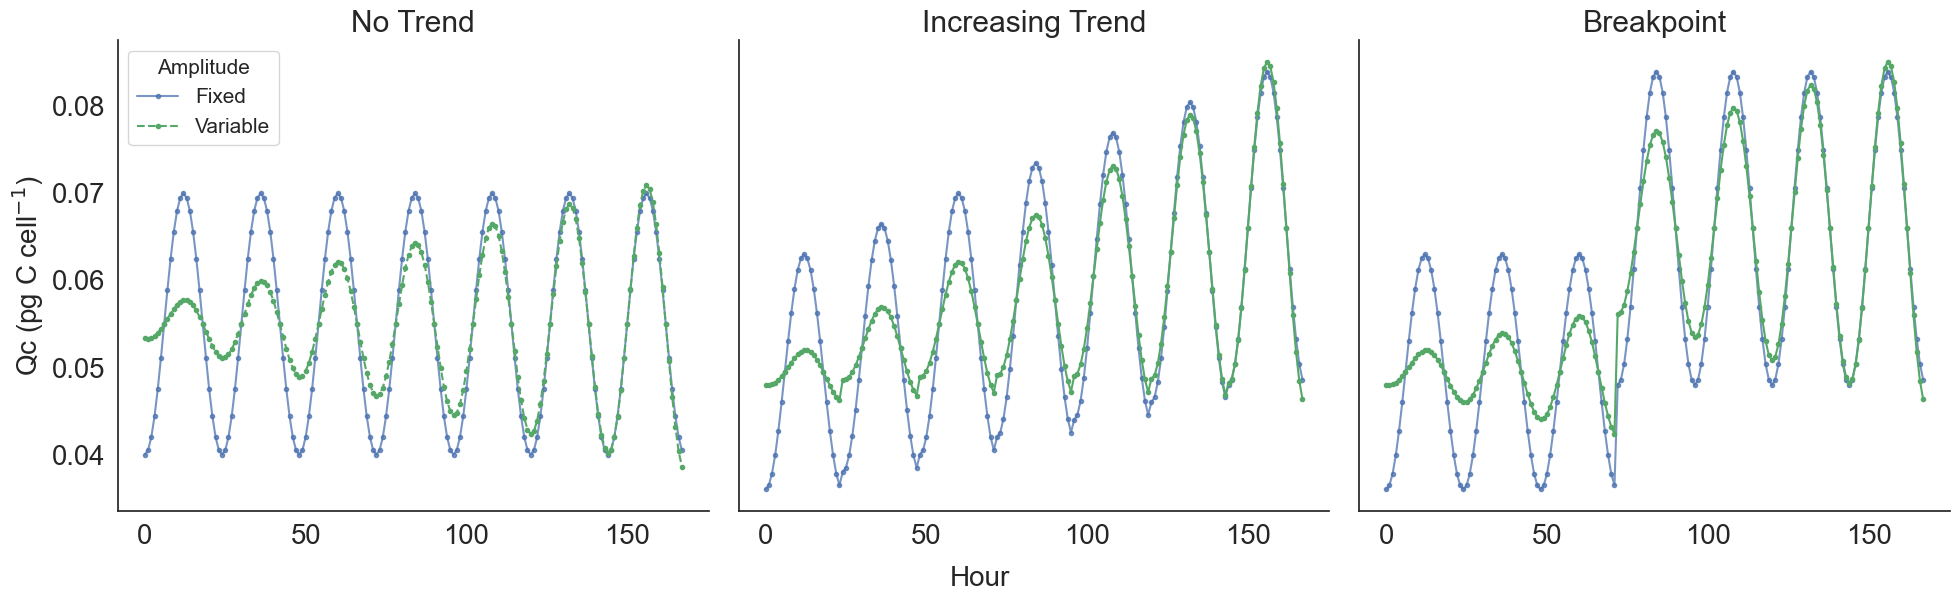

In [198]:
### Show simulated data (fig 1 panel A)
sns.set_style('white')
# show simulation data
fig,axs=plt.subplots(figsize=(20,6), ncols=3, sharey=True)
## plot scenario 1
ln1=axs[0].plot(new_wave, marker='.', label='Fixed', alpha=0.75)
d1=axs[0].plot(sim_df['moving_data1'], marker='.', c='g',linestyle='--',label='Variable')
lns=ln1+d1
labs = [l.get_label() for l in lns]
axs[0].legend(lns,labs, title = 'Amplitude', loc='upper left', fontsize = 15, title_fontsize=15)
axs[0].set_title('No Trend')
axs[0].set_ylabel('Qc (pg C cell$^{-1}$)', size=20)

## plot scenario 2
ln2=axs[1].plot(data2, marker='.', label='3', alpha=0.75)
d3=axs[1].plot(sim_df['moving_data2'], marker='.', c='g', label='4')
lns=ln2+d3
labs = [l.get_label() for l in lns]
# axs[1].legend(lns,labs, title = 'Scenarios', loc='upper left', fontsize = 12, title_fontsize=12)
axs[1].set_title('Increasing Trend')


## plot scenario 3
ln3=axs[2].plot(breaks, marker='.', label='5', alpha=0.75)
d3=axs[2].plot(sim_df['moving_data3'], marker='.', c='g', label='6')
lns=ln3+d3
labs = [l.get_label() for l in lns]
# axs[2].legend(lns,labs, title = 'Scenarios', loc='upper left', fontsize = 12, title_fontsize=12)
axs[2].set_title('Breakpoint')

# add text and set font size

fig.text(0.5, -0.01, 'Hour', ha='center', size=20)
plt.rcParams.update({'font.size':20})
# remove top and right spines for all axes
for ax in axs: 
    ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()

### Plot aggregated results of simulations, scenarios 1 - 6


#### Panels B-C

In [255]:
# get rmse for each day in each resulting df, add cols for plotting
noise_error = noise_tsd_all.groupby(['model', 'scenario', 'noise', 'bootstrap_run']).mean().reset_index()
noise_error.rename(columns = {'noise': 'data level'}, inplace=True)
noise_error['trial'] = 'Added Noise'
remove_error = remove_tsd_all.groupby(['model', 'scenario', 'remove', 'bootstrap_run']).mean().reset_index()
remove_error.rename(columns = {'remove': 'data level'}, inplace=True)
remove_error['trial'] = 'Missing Data'
# create aggregated file
all_trials = pd.concat([noise_error, remove_error])

# Distinguish between Scnarios 1-3 and 4-6
all_trials.loc[all_trials['scenario'] < 4, 'diel'] = 'Fixed Amplitude'
all_trials.loc[all_trials['scenario'] >= 4, 'diel'] = 'Variable Amplitude'

# group scenario types by trends
all_trials.loc[(all_trials['scenario'] == 1) | (all_trials['scenario'] == 4), 'trend'] = 'No Trend'
all_trials.loc[(all_trials['scenario'] == 2) | (all_trials['scenario'] == 5), 'trend'] = 'Increasing Trend'
all_trials.loc[(all_trials['scenario'] == 3) | (all_trials['scenario'] == 6), 'trend'] = 'Breakpoint'

### NEED TO FIX BASE MODEL CALCULATION

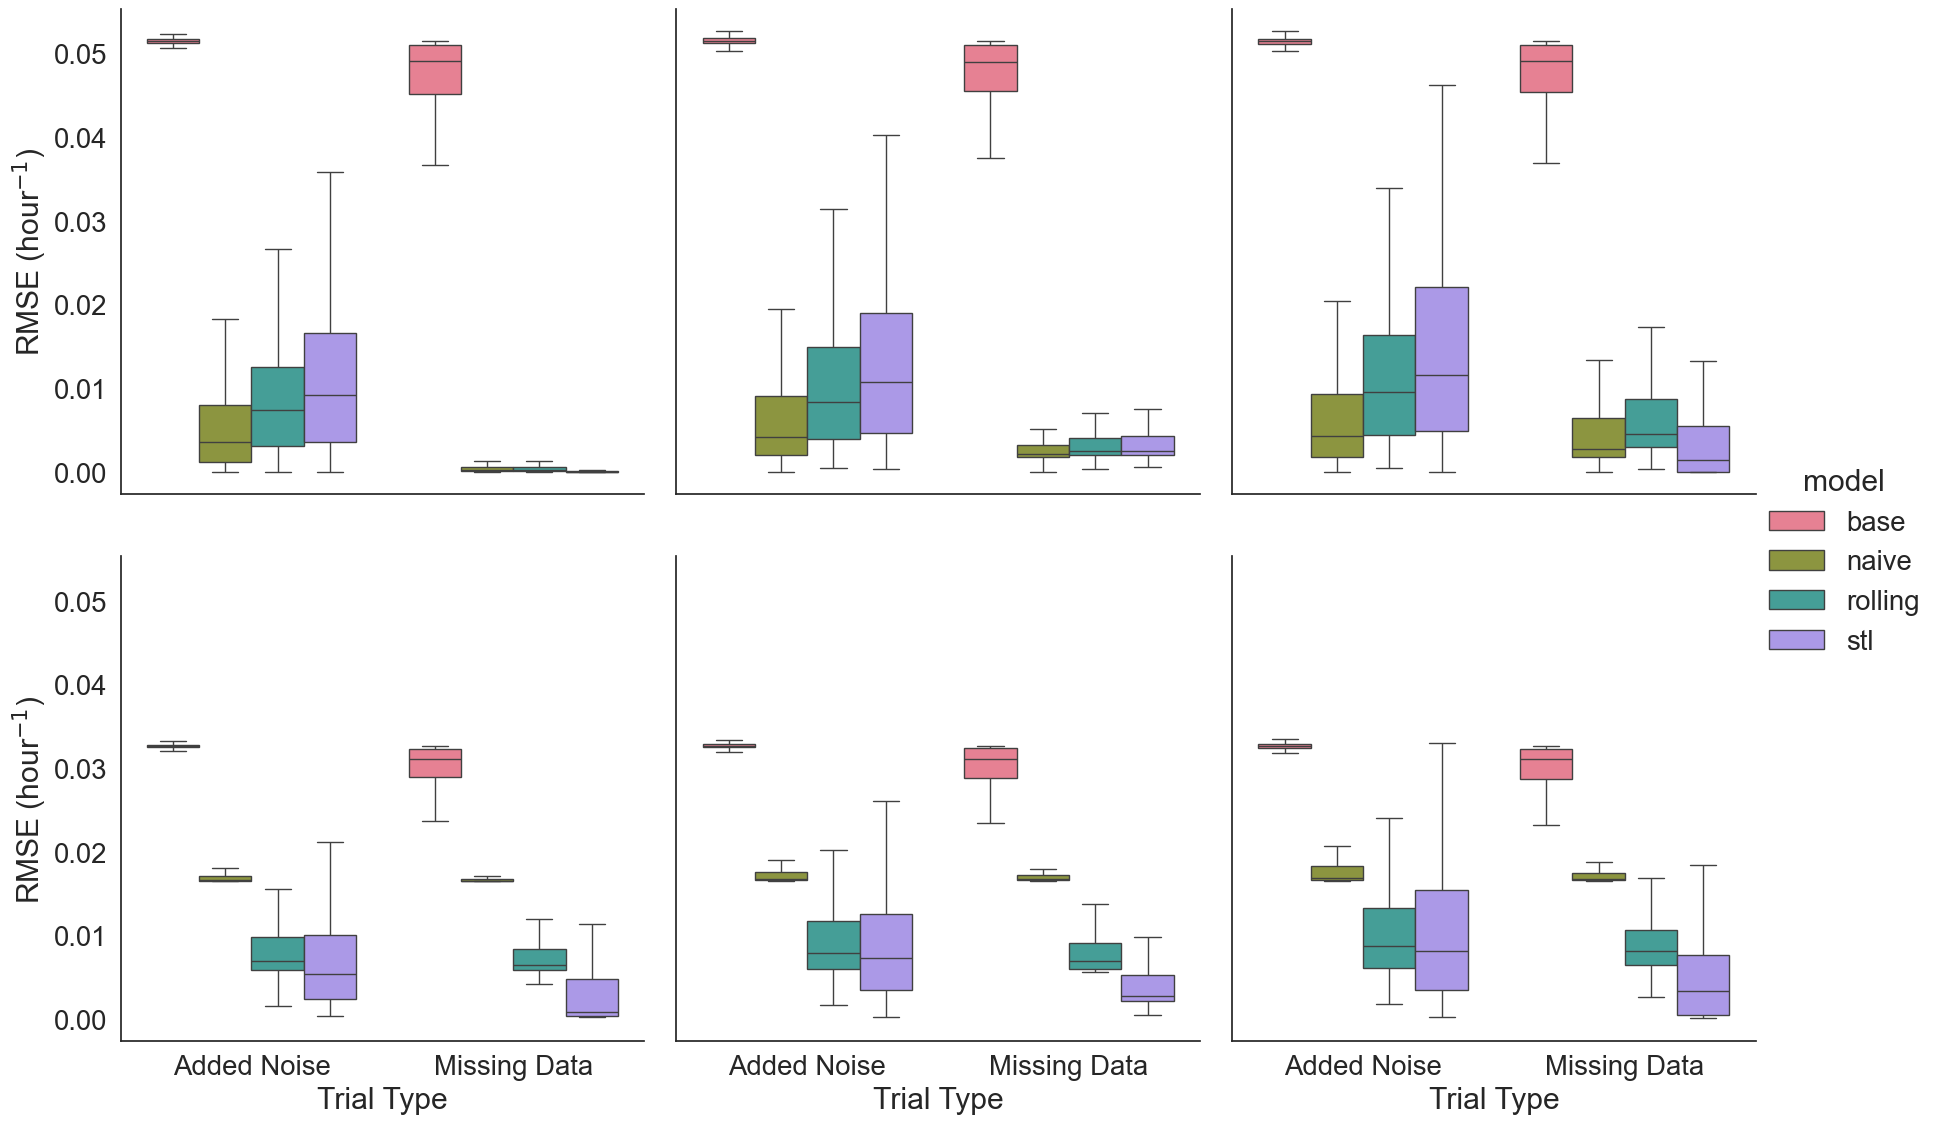

In [257]:
sns.set_theme(font_scale=1.8)
sns.set_style(style='white')
hue_order = ['base', 'naive', 'rolling', 'stl']
g = sns.catplot(data=all_trials, x='trial', y='rmse', hue='model', col='trend',
                row='diel', kind='box',palette='husl',
               errorbar='se',height=6, hue_order=hue_order, showfliers=False)
# plt.legend()
g.set_axis_labels("Trial Type",'RMSE (hour$^{-1}$)')
g.set_titles(template="")
plt.show()

### Supplementary figure with all data levels

#### Constant Diel 

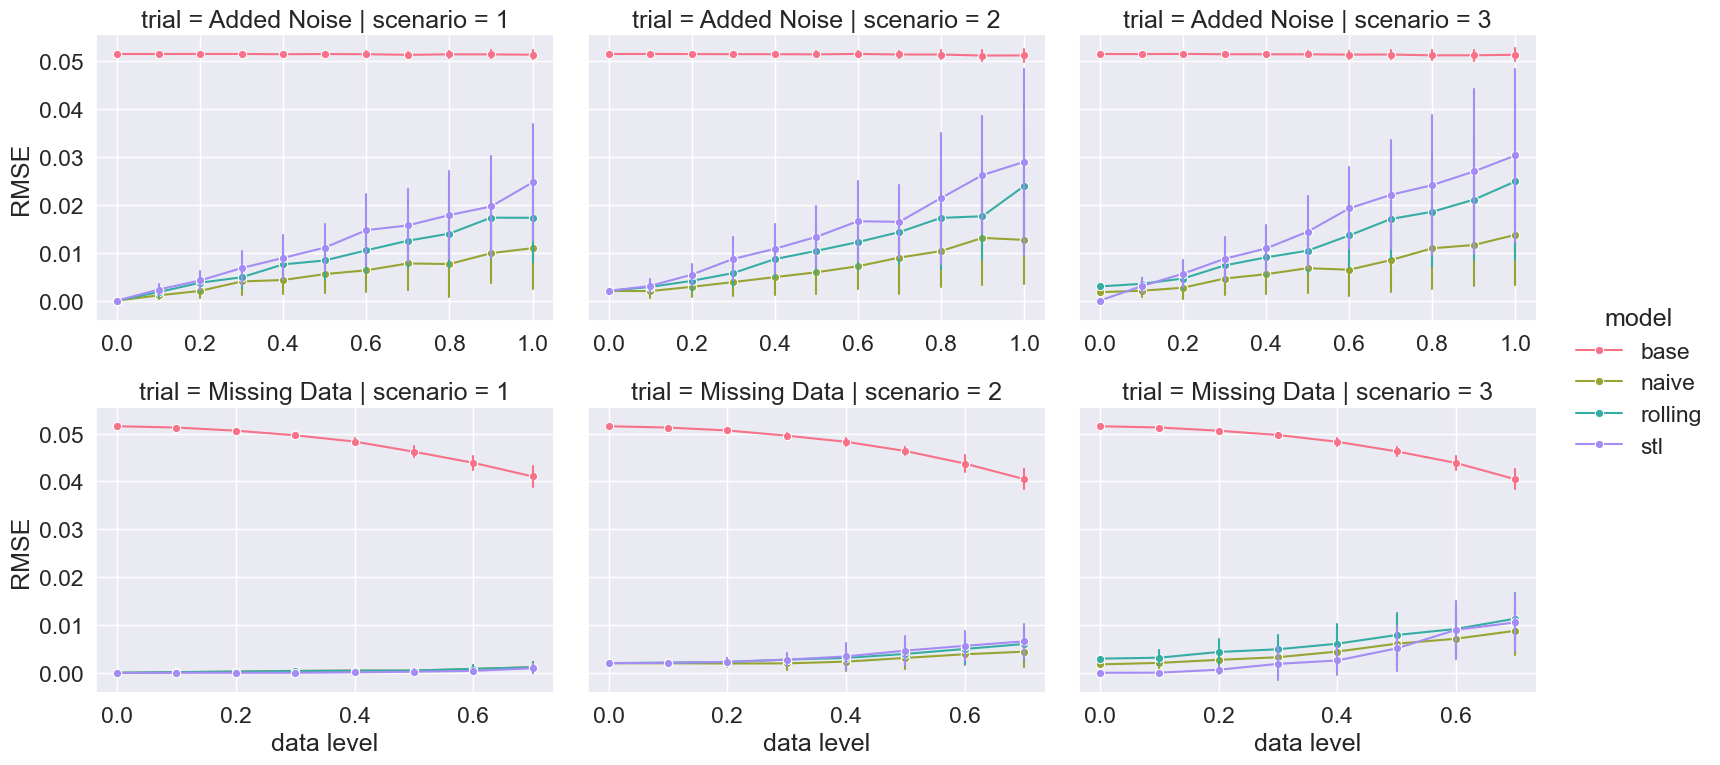

In [276]:
# plot increasing data removed
sns.set(font_scale=1.5)
constant_diel_df = all_trials.loc[all_trials['diel'] == 'Fixed Amplitude']
g = sns.FacetGrid(constant_diel_df, col="scenario", row='trial', hue='model',sharey=True, sharex=False,
                 height=4, aspect=1.2, palette = 'husl')
g.map(sns.lineplot, "data level", "rmse", marker='o',err_style='bars',ci='sd', legend = True)
g.add_legend(bbox_to_anchor=(1, 0.5), loc='center left', borderaxespad=0.)
# g.set_axis_labels("Noise Added")
axes = g.axes.flatten()
axes[0].set_ylabel('RMSE')
axes[3].set_ylabel('RMSE')
plt.tight_layout()
plt.show()

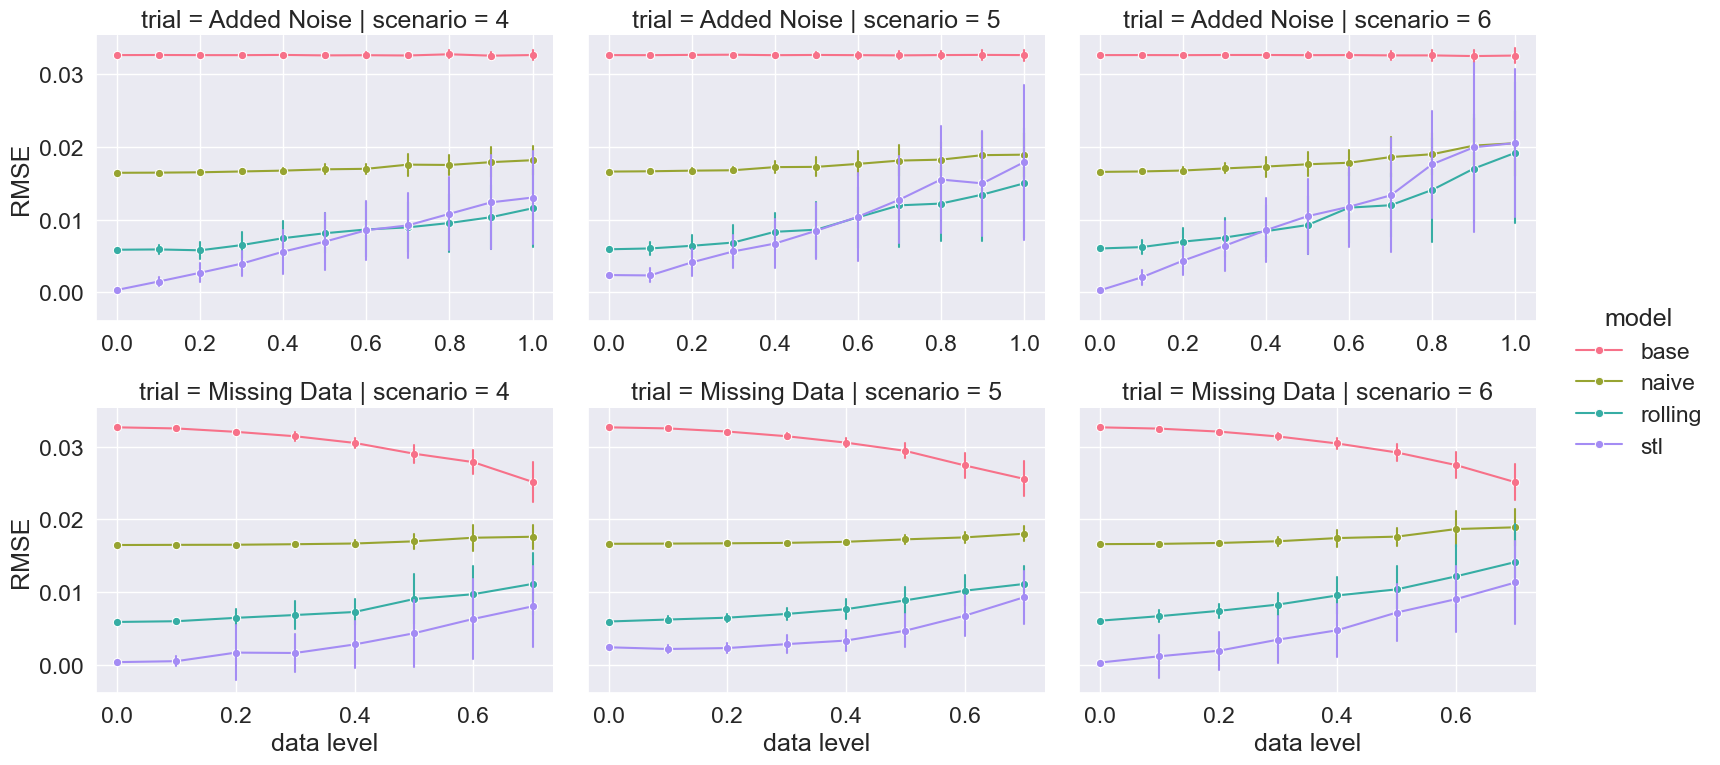

In [277]:
# plot increasing data removed
sns.set(font_scale=1.5)
var_diel_df = all_trials.loc[all_trials['diel'] == 'Variable Amplitude']
g = sns.FacetGrid(var_diel_df, col="scenario", row='trial', hue='model',sharey=True, sharex=False,
                 height=4, aspect=1.2, palette = 'husl')
g.map(sns.lineplot, "data level", "rmse", marker='o',err_style='bars',ci='sd', legend = True)
g.add_legend(bbox_to_anchor=(1, 0.5), loc='center left', borderaxespad=0.)
# g.set_axis_labels("Noise Added")
axes = g.axes.flatten()
axes[0].set_ylabel('RMSE')
axes[3].set_ylabel('RMSE')
plt.tight_layout()
plt.show()